# **Logistic Regression**

In [3]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Initialization of data
# TODO

Hyperplane

In [5]:
def h(x, w0, w1):
  return np.dot(w1.T, x) + w0 

Hypothesis
$$ S(x) = \frac{1}{1 + e^{-h(x)}}$$

In [11]:
def S(x):
    return 1/(1+np.exp(-h(x)))


Error Function

In [10]:
def error(x, y, w0, w1):
    h_x = h(x, w0, w1)
    n = x.shape[1]
    L = -1 * np.sum(((np.log(h_x))*y + (np.log(1-h_x))*(1-y)))/n
    return L

Derivative Function

In [ ]:
def derivative(x, y):
    n = x.shape[1]
    d_w0 = np.sum((y - S(x)) * (-1))/n
    d_w1 = np.sum(y - S(x) * (-x))/n
    return d_w0, d_w1

In [30]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [31]:
arrL = []

def train(x, y, alfa, dim, epochs):
  # w = np.array([np.random.rand() for i in range(p+1)])     # k+1 parametros w0 + w1x1 + ... wkxk
  w1 = np.zeros((dim,1))
  w0 = 0
 
  # display(x)
  # display(w)
  i = 0
  for _ in range(epochs):
    L = error(x, y, w_0, w_1)     
    arrL.append(L)
    
    d_w0, d_w1 = derivative(x, y)
    w0 = update(w0 ,alfa, d_w0)     
    w1 = update(w1 ,alfa, d_w1)     
    
    if _ % 50 == 0:
      print(f"L: {L} ", end="")
    if _ % 100 == 0:
      print()
    
  return w0, w1

In [32]:
def test(x, y, w0, w1, p):
   print(f'Error: {error(x, y, w0, w1)}')

   # 2D PLOT
   fig = plt.figure()
   plt.title("Error function along training")
   plt.ylabel("L")
   plt.xlabel("epochs")
   plt.plot(np.arange(1,len(arrL)+1), arrL)

   # 2D FUNCTION PLOT
   xAxis = np.linspace(-0.5, 1, 100)
   yAxis = paramArr[0]
   title = str(round(paramArr[0],2))
   for i in range(1, p+1):
      yAxis += paramArr[i]*(xAxis**i)
      title += " + " + str(round(paramArr[i],2)) + f"*x^{i}"
   
   fig = plt.figure()
   plt.title("Univariable Non-Linear Regression")
   plt.scatter(trainX, trainY, color="green", alpha=0.5)
   plt.scatter(testX, testY, color="red", alpha=0.5)
   
   plt.plot(xAxis, yAxis, 'b', label=title)
   plt.legend(loc= 3, prop={'size': 5.5})

In [33]:
# EXTEND ARRAY
p = 6
epochs = 3000
alfa = 0.5 #0.08568769 # 0.0092795823740238
lambdita = 0.0234891

auxX = []
for feature in trainX:         # feature np.array int
    nRow = []
    for i in range(p+1):
        nRow.append(feature**i)
    auxX.append(nRow)
extendX = np.array(auxX)
display(extendX)

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 7.96178344e-04, 6.33899955e-07, ...,
        4.01829153e-13, 3.19927670e-16, 2.54719482e-19],
       [1.00000000e+00, 2.38853503e-03, 5.70509960e-06, ...,
        3.25481614e-11, 7.77424238e-14, 1.85690503e-16],
       ...,
       [1.00000000e+00, 9.97611465e-01, 9.95228635e-01, ...,
        9.90480036e-01, 9.88114240e-01, 9.85754094e-01],
       [1.00000000e+00, 9.98407643e-01, 9.96817822e-01, ...,
        9.93645771e-01, 9.92063532e-01, 9.90483813e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]])

In [34]:
arrL = []
paramArr = train(extendX, trainY, alfa , p, epochs, lambdita)
paramArr

L: 0.9910316670101822 
L: 0.030351283887444947 L: 0.024564969870380555 
L: 0.022949897116504553 L: 0.022578123245159704 
L: 0.022534098095772552 L: 0.0225633819884324 
L: 0.022615337391241035 L: 0.02269376393228518 
L: 0.02281135187180326 L: 0.022977874079032973 
L: 0.023198555354547304 L: 0.023475002993975546 
L: 0.023806427562156444 L: 0.024190600795276365 
L: 0.02462450341672487 L: 0.02510473433205015 
L: 0.02562775889634017 L: 0.02619005490781724 
L: 0.02678819561479568 L: 0.02741889465775678 
L: 0.02807902831515742 L: 0.028765644381325707 
L: 0.02947596328470461 L: 0.030207374796675096 
L: 0.030957432322076945 L: 0.0317238459486143 
L: 0.032504474946470394 L: 0.033297320120115145 
L: 0.03410051624234001 L: 0.03491232469861017 
L: 0.03573112640957979 L: 0.036555415064182556 
L: 0.037383790675029976 L: 0.03821495345593084 
L: 0.03904769801462028 L: 0.03988090785013498 
L: 0.04071355014242945 L: 0.041544670821048096 
L: 0.04237338989950042 L: 0.04319889706217284 
L: 0.044020447490988

array([ 0.76863391,  1.04824654, -2.45504581, -1.71870512,  0.0065896 ,
        0.98683151,  2.03430678])

Error: 0.05825312445444842


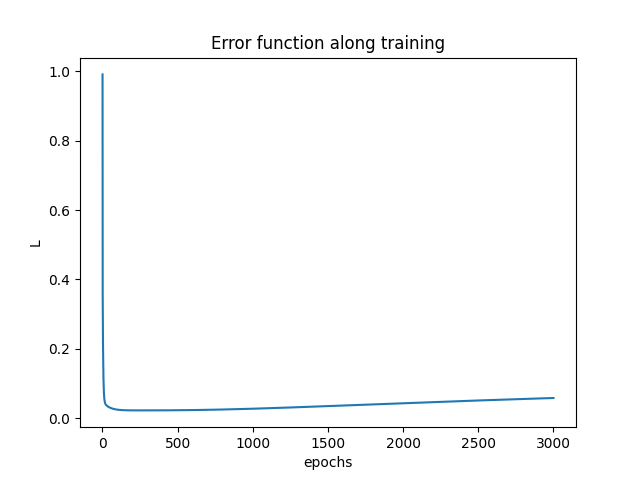

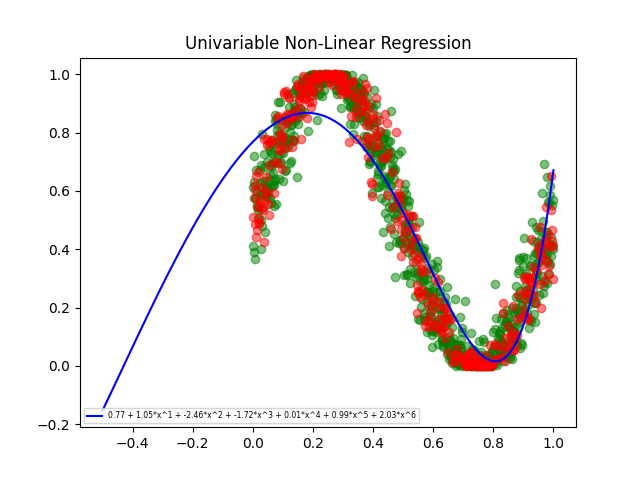

In [35]:
test(extendX, trainY, paramArr, p, lambdita)